In [1]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pandas

kode diatas mengimpor beberapa library yang dibutuhkan. cv2 digunakan untuk membaca dan mengolah gambar, numpy dipakai karena gambar tersebut sebenarnya berupa array atau matriks angka, dan matplotlib digunakan untuk menampilkan gambar ke layar.

Kode di bawah ini membaca file gambar `background.PNG` menggunakan OpenCV lalu menampilkannya dengan `matplotlib`; hasilnya gambar akan muncul di notebook tanpa perlu menyimpan kembali, jadi kita bisa langsung melihat isi gambar yang dibaca.

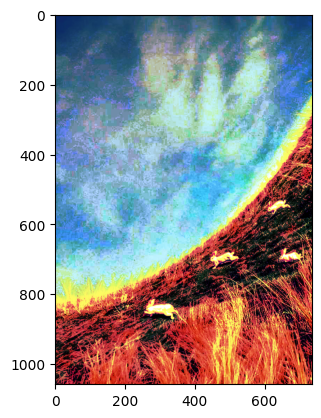

In [2]:
background = cv2.imread('Assets/background.PNG')
plt.imshow(background)
plt.show()

Kode di bawah ini pertama mengubah format warna gambar dari BGR yang biasa dipakai OpenCV jadi RGB supaya tampilannya benar di matplotlib, lalu memisahkan masing-masing komponen warna ke dalam variabel `blue`, `green`, dan `red`. Setelah itu dibuat figur dengan tiga subplot, masing-masing menampilkan satu channel warna secara terpisah: channel merah dengan palet `Reds`, hijau dengan `Greens`, dan biru dengan `Blues`, sehingga kita bisa melihat kontribusi tiap channel warna terhadap gambar asli.

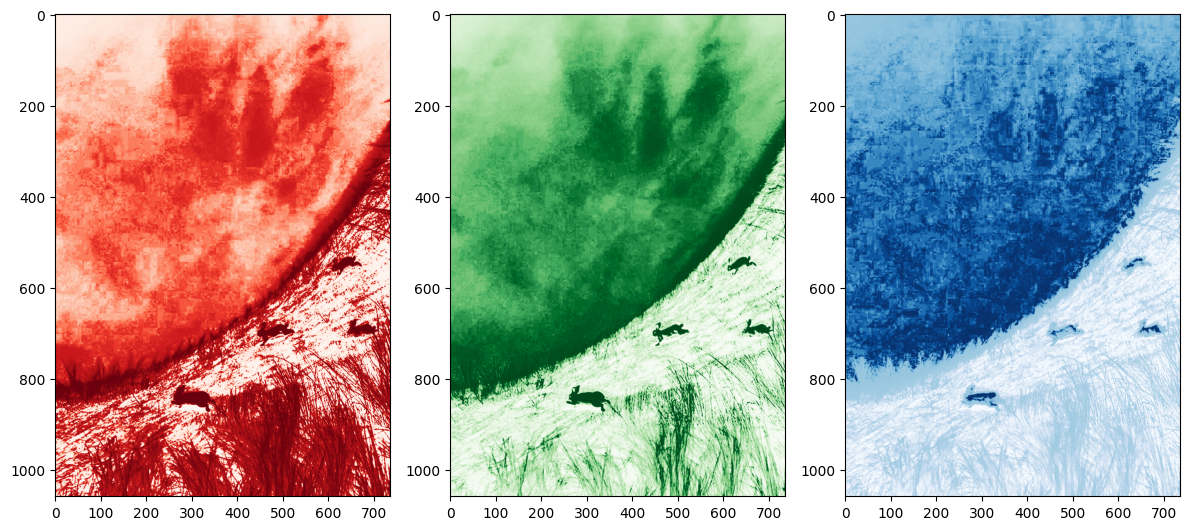

In [3]:
background = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)

blue = background[:, :, 0]
green = background[:, :, 1]
red = background[:, :, 2]

plt.figure(figsize=(12, 8))
plt.subplot(1, 3, 1)
plt.imshow(red, cmap='Reds')

plt.subplot(1, 3, 2)
plt.imshow(green, cmap='Greens')

plt.subplot(1, 3, 3)
plt.imshow(blue, cmap='Blues')

plt.tight_layout()
plt.show()

In [4]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

Fungsi `buat_hist` di atas digunakan untuk menghitung berapa banyak piksel dengan nilai intensitas tertentu di dalam citra, dimulai dari membuat daftar kosong berukuran 256 lalu menghitung setiap piksel satu per satu untuk menaikkan jumlah pada indeks yang sesuai, sedangkan `plot_histogram` mengambil hasil hitungan tersebut lalu menampilkannya dalam bentuk diagram batang dengan judul, label sumbu, dan warna yang sesuai sehingga kita bisa melihat distribusi intensitas piksel dalam citra secara visual.

Kode di bawah ini menghitung distribusi intensitas piksel untuk masing-masing saluran warna merah, hijau, dan biru dengan memanggil fungsi `buat_hist`, lalu hasil hitungan itu langsung ditampilkan sebagai grafik batang melalui `plot_histogram` dengan judul yang sesuai, sehingga kita bisa melihat seberapa banyak piksel yang memiliki nilai kecerahan tertentu di setiap channel warna.

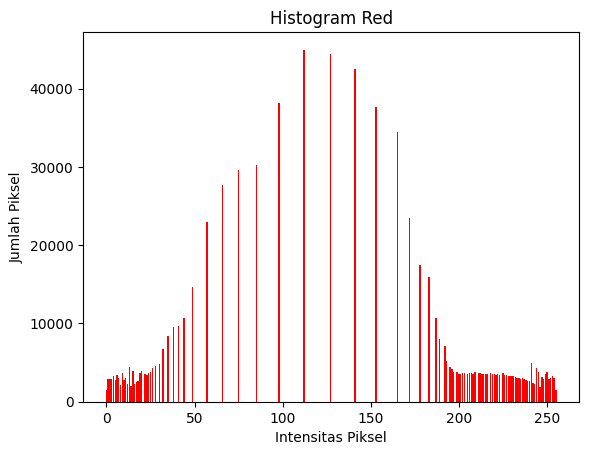

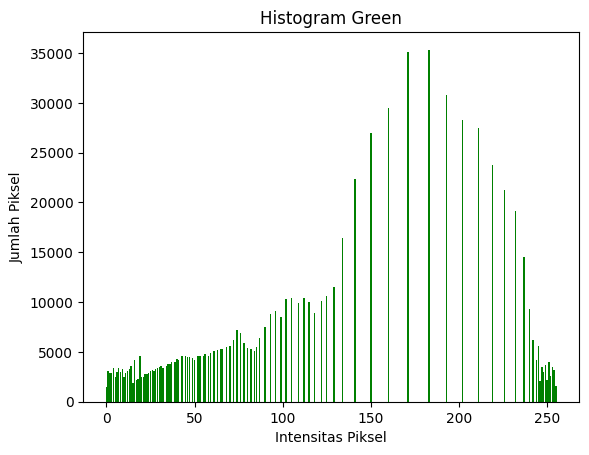

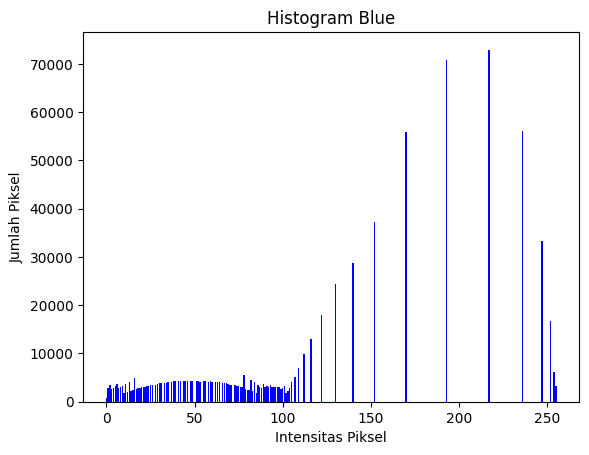

In [5]:
histogram_red = buat_hist(red)
plot_histogram(histogram_red, "Histogram Red", "red")

histogram_green = buat_hist(green)
plot_histogram(histogram_green, "Histogram Green", "green")

histogram_blue = buat_hist(blue)
plot_histogram(histogram_blue, "Histogram Blue", "blue")

Kode di bawah ini membaca tiga gambar target yang berbeda dalam mode grayscale lalu menampilkan semuanya secara berdampingan dalam satu figure, yaitu `blue_target` dengan palet warna biru, `green_target` dengan palet warna hijau, dan `red_target` dengan palet warna merah, sehingga kita bisa langsung melihat perbedaan masing-masing komponen warna target tersebut di layar.

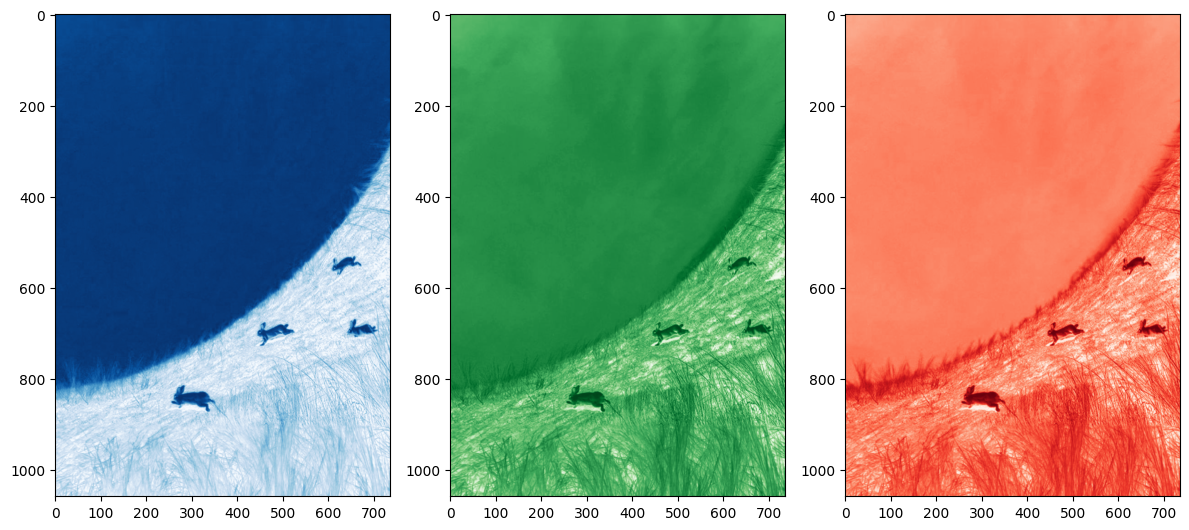

In [6]:
blue_target = cv2.imread('Assets/blue_target.PNG', 0)
plt.figure(figsize=(12, 8))
plt.subplot (1, 3, 1)
plt.imshow(blue_target, cmap='Blues')

green_target = cv2.imread('Assets/green_target.PNG', 0)
plt.subplot (1, 3, 2)
plt.imshow(green_target, cmap='Greens')

red_target = cv2.imread('Assets/red_target.PNG', 0)
plt.subplot (1, 3, 3)
plt.imshow(red_target, cmap='Reds')

plt.tight_layout()
plt.show()

Kode di bawah ini menghitung distribusi intensitas piksel untuk setiap channel warna target dengan memanggil fungsi `buat_hist`, lalu setiap hasil histogram tersebut langsung ditampilkan dengan `plot_histogram` menggunakan judul dan warna yang sesuai sehingga kita bisa melihat sebaran kecerahan di channel merah, hijau, dan biru secara terpisah.

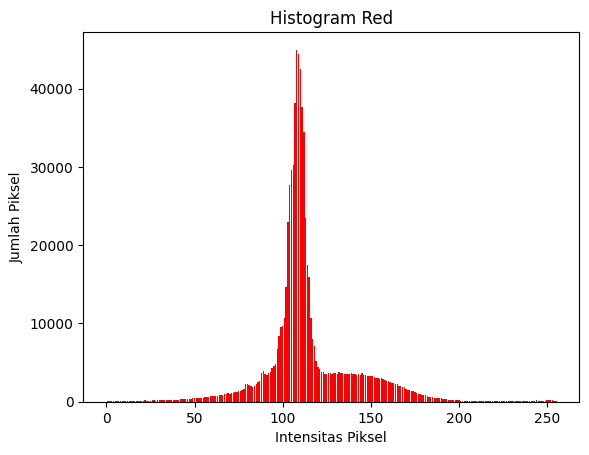

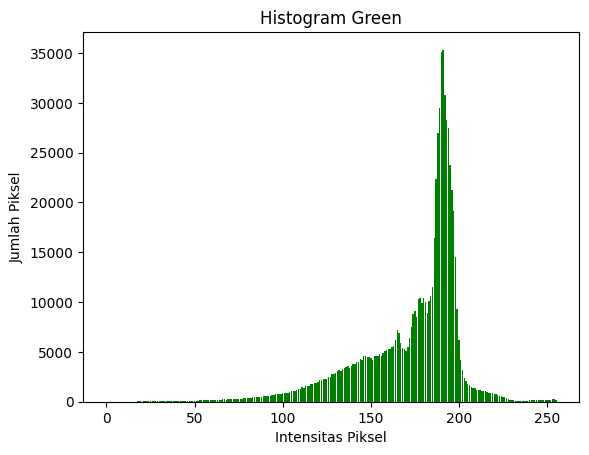

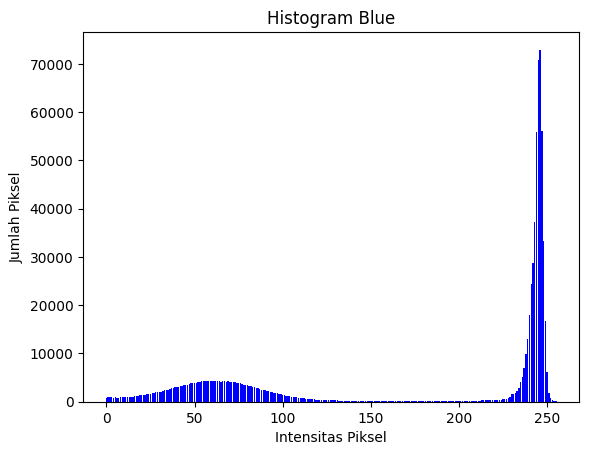

In [7]:
histogram_red_target = buat_hist(red_target)
plot_histogram(histogram_red_target, "Histogram Red", "red")

histogram_green_target = buat_hist(green_target)
plot_histogram(histogram_green_target, "Histogram Green", "green")

histogram_blue_target = buat_hist(blue_target)
plot_histogram(histogram_blue_target, "Histogram Blue", "blue")

In [8]:
def spesifikasi_hist(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
    height_asal, width_asal = citra_asal.shape
    for i in range(height_asal):
        for j in range(width_asal):
            pixel = citra_asal[i, j]
            hist_asal[pixel] += 1
 
    height_target, width_target = citra_target.shape
    for i in range(height_target):
        for j in range(width_target):
            pixel = citra_target[i, j]
            hist_target[pixel] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    for i in range(256):
        selisih_terkecil = 1.0 
        index_target = 0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                index_target = j
        map_hist[i] = index_target
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    for i in range(height):
        for j in range(width):
            pixel_lama = citra_asal[i, j]
            hasil[i, j] = map_hist[pixel_lama]
 
    return hasil

Fungsi di atas `spesifikasi_hist` membuat citra asli punya sebaran intensitas yang mirip dengan citra target, dengan cara pertama-tama menghitung berapa banyak piksel di setiap nilai intensitas untuk kedua citra, lalu mengubah hitungan itu menjadi distribusi kumulatif yang dinormalisasi agar bisa dibandingkan, selanjutnya untuk setiap nilai intensitas di citra asal dicari nilai intensitas di citra target yang punya selisih CDF terkecil sehingga dapat dibuat peta pemetaan, dan akhirnya citra asal diubah per piksel menggunakan peta tersebut sehingga hasilnya memiliki karakteristik histogram yang mendekati target.

Kode di bawah ini melakukan spesifikasi histogram untuk masing-masing channel warna dengan memanggil fungsi `spesifikasi_hist` pada channel merah, hijau, dan biru dari gambar asli terhadap targetnya, lalu menampilkan hasilnya dalam satu figure yang terdiri dari tiga subplot sehingga kita bisa membandingkan bagaimana tiap channel berubah setelah disesuaikan dengan target warna.

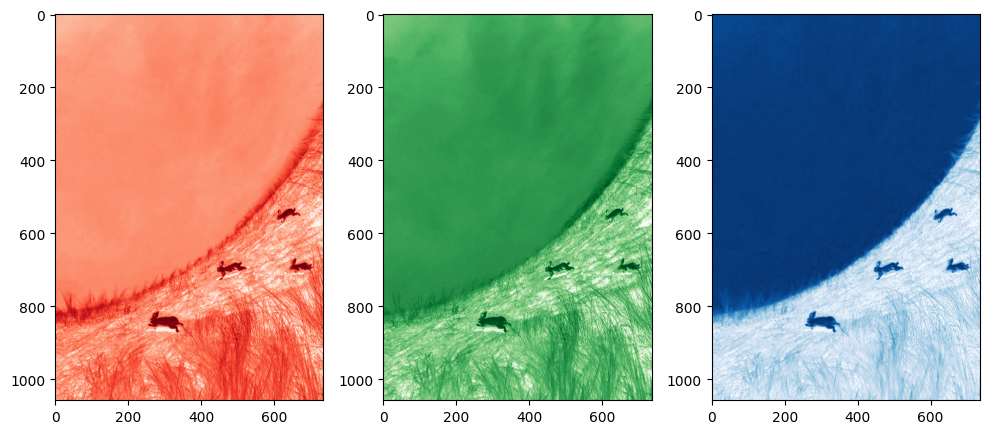

In [9]:
spesifikasi_red = spesifikasi_hist(red, red_target)
spesifikasi_green = spesifikasi_hist(green, green_target)
spesifikasi_blue = spesifikasi_hist(blue, blue_target)

plt.figure(figsize=(10, 7))

plt.subplot(1, 3, 1)
plt.imshow(spesifikasi_red, cmap='Reds')

plt.subplot(1, 3, 2)
plt.imshow(spesifikasi_green, cmap='Greens')

plt.subplot(1, 3, 3)
plt.imshow(spesifikasi_blue, cmap='Blues')
plt.tight_layout()
plt.show()

In [10]:
def merge_channel(r_channel, g_channel, b_channel):
    height = len(r_channel)
    width = len(r_channel[0])
    
    hasil = np.zeros((height, width, 3), dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            hasil[i][j][0] = r_channel[i][j] 
            hasil[i][j][1] = g_channel[i][j] 
            hasil[i][j][2] = b_channel[i][j]
            
    return hasil

Kode di atas membuat fungsi untuk menggabungkan tiga channel warna menjadi satu gambar RGB, di mana `r_channel`, `g_channel`, dan `b_channel` masing-masing berisi informasi intensitas untuk warna merah, hijau, dan biru. Pertama fungsi menentukan ukuran gambar dari channel merah, lalu membuat array kosong dengan tiga dimensi untuk menampung hasil gabungan, setelah itu setiap piksel diisi dengan nilai dari ketiga channel sesuai posisi yang sama. Dengan begitu, hasil yang dikembalikan menjadi sebuah gambar warna lengkap yang bisa ditampilkan sebagai RGB.

Kode di bawah ini menggabungkan ketiga channel hasil spesifikasi histogram menjadi satu gambar warna utuh, lalu menampilkan dua gambar secara berdampingan: gambar asli dan hasil setelah spesifikasi histogram. Dengan `plt.subplot(1, 2, ...)` dibuat dua kolom, satu untuk menampilkan `background` dan satu untuk `hasil_gabungan`, masing-masing diberi judul agar lebih mudah dibandingkan, lalu `plt.tight_layout()` memastikan tata letaknya rapi sebelum ditampilkan.

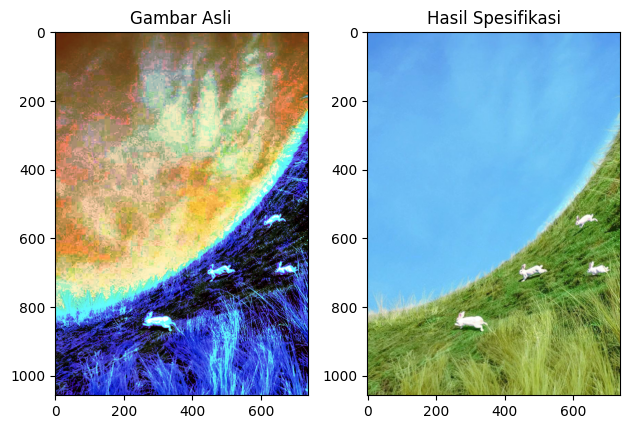

In [11]:
hasil_gabungan = merge_channel(spesifikasi_red, spesifikasi_green, spesifikasi_blue)
plt.subplot(1, 2, 1)
plt.imshow(background)
plt.title("Gambar Asli")

plt.subplot(1, 2, 2)
plt.imshow(hasil_gabungan)
plt.title("Hasil Spesifikasi")

plt.tight_layout()
plt.show()

Kode di bawah ini membaca gambar `foreground.png` menggunakan OpenCV lalu mengubah format warnanya dari BGR ke RGB supaya tampilannya benar di `matplotlib`, kemudian menampilkan gambar tersebut dengan judul "Foreground" dan mencetak ukuran array gambar ke layar untuk melihat dimensi gambar yang sudah dibaca.

(529, 368, 3)


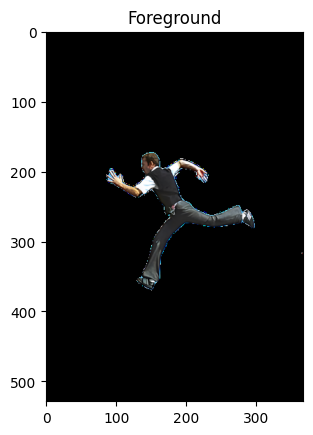

In [12]:
foreground = cv2.imread('Assets/foreground.png')
foreground = cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)
plt.imshow(foreground)
plt.title("Foreground")
print(foreground.shape)

In [13]:
def fungsi_dilatasi(image):
    h,w = image.shape
    dilated = np.zeros((h * 2, w * 2), dtype=image.dtype)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y/2)][int(x/2)]

    return dilated

Fungsi `fungsi_dilatasi` di atas itu menerima gambar grayscale lalu memperbesar ukuran gambar dua kali lipat dengan cara membuat array baru kosong berukuran `h * 2` dan `w * 2`, kemudian setiap piksel di gambar baru diisi dengan piksel dari gambar asli berdasarkan pembagian indeks `y` dan `x` dengan 2, jadi satu piksel asli akan direplikasi menjadi empat piksel pada gambar hasil, sehingga terlihat seperti gambar yang diperbesar dengan efek blok-blok.

Kode di bawah ini mengambil tiga komponen warna dari gambar `foreground` yaitu biru, hijau, dan merah, lalu memperbesar masing-masing channel tersebut menggunakan fungsi dilatasi sehingga setiap channel menjadi lebih besar dan terlihat seperti diperbesar dengan blok-blok. Setelah itu ketiga channel hasil dilatasi digabung lagi menjadi satu gambar warna penuh dengan `merge_channel`, lalu ditampilkan dalam satu baris plot: tiga subplot pertama menampilkan channel merah, hijau, dan biru secara terpisah dengan map warna masing-masing, sedangkan subplot terakhir menunjukkan hasil gabungan akhir dari ketiga channel tersebut.

Text(0.5, 1.0, 'Final Result')

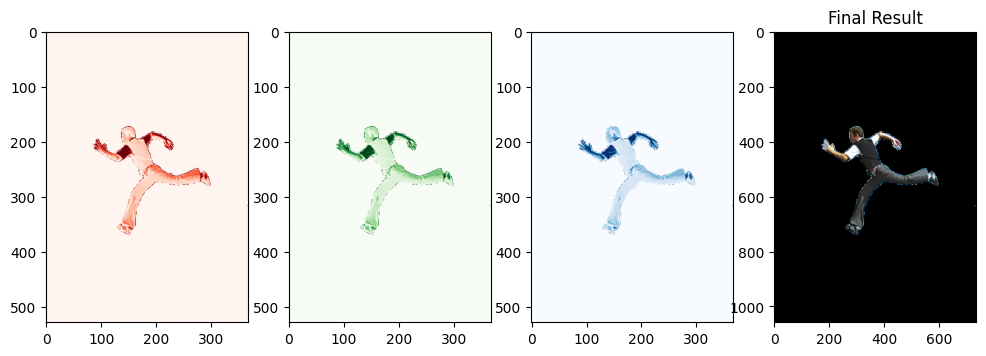

In [14]:
blue_foreground = foreground[:, :, 0]
green_foreground = foreground[:, :, 1]
red_foreground = foreground[:, :, 2]

red_dil = fungsi_dilatasi(red_foreground)
green_dil = fungsi_dilatasi(green_foreground)
blue_dil = fungsi_dilatasi(blue_foreground)

hasil_dil = merge_channel(blue_dil, green_dil, red_dil)

plt.figure(figsize=(12, 7))

plt.subplot(1, 4, 1)
plt.imshow(red_foreground, cmap='Reds')

plt.subplot(1, 4, 2)
plt.imshow(green_foreground, cmap='Greens')

plt.subplot(1, 4, 3)
plt.imshow(blue_foreground, cmap='Blues')

plt.subplot(1, 4, 4)
plt.imshow(hasil_dil)
plt.title("Final Result")


In [15]:
def gabung_citra(fg, bg):
    h, w, c = fg.shape
    hasil = np.zeros((h, w, c), dtype=np.uint8)
    
    for i in range(h):
        for j in range(w):
            b = fg[i][j][0]
            g = fg[i][j][1]
            r = fg[i][j][2]

            if r > 0 or g > 0 or b > 0:
                hasil[i][j] = fg[i][j]
            else:
                hasil[i][j] = bg[i][j]
                
    return hasil

Fungsi `gabung_citra` di atas ini bekerja dengan menggabungkan dua gambar, di mana ia memeriksa setiap piksel di gambar depan (`fg`) dan kalau piksel itu bukan hitam total (artinya salah satu nilai merah, hijau, atau birunya lebih dari nol) maka nilai piksel tersebut dipakai, tapi kalau pikselnya hitam semua maka diganti dengan piksel yang sama posisinya dari gambar latar (`bg`), jadi hasilnya adalah gabungan yang mempertahankan bagian berwarna dari foreground dan mengisi bagian hitamnya dengan background.

Kode di bawah ini menggabungkan dua citra hasil proses sebelumnya menggunakan fungsi `gabung_citra`, lalu menampilkan hasil gabungan tersebut sebagai gambar dengan judul "Hasil Citra Gabungan" dan juga mencetak ukuran dimensi array gambar untuk memberi tahu berapa lebar, tinggi, dan channel warnanya.

(1058, 736, 3)


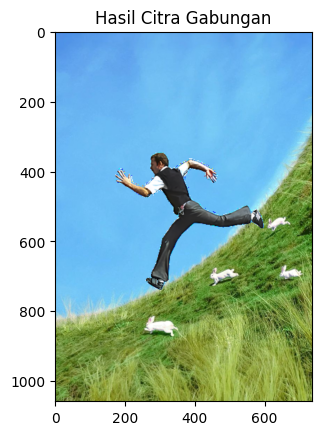

In [16]:
final_citra = gabung_citra(hasil_dil, hasil_gabungan)

plt.imshow(final_citra)
plt.title("Hasil Citra Gabungan")
print(final_citra.shape)
plt.show()

Kode di bawah ini pertama mengubah gambar hasil akhir (`final_citra`) menjadi citra keabuan (`final_grayscale`) menggunakan fungsi OpenCV, supaya setiap piksel hanya memiliki nilai intensitas tanpa informasi warna, lalu menghitung distribusi intensitas piksel tersebut dengan memanggil fungsi `buat_hist`, dan akhirnya menampilkan hasil perhitungan itu dalam bentuk histogram berwarna merah dengan judul "Histogram Gabungan".

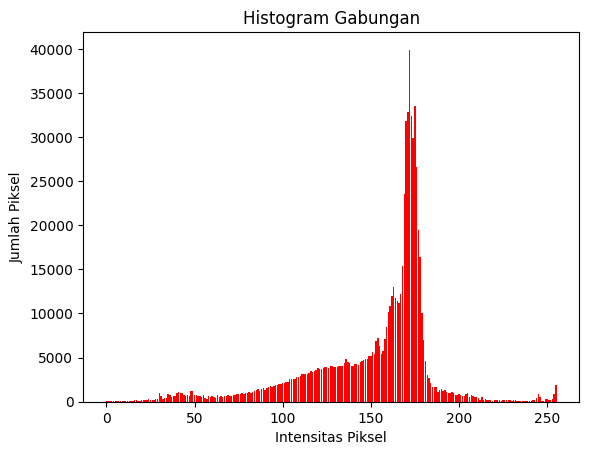

In [17]:
final_grayscale = cv2.cvtColor(final_citra, cv2.COLOR_RGB2GRAY)
histogram_gabungan = buat_hist(final_grayscale)
plot_histogram(histogram_gabungan, "Histogram Gabungan", "red")

In [18]:
def fungsi_slicing(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

Fungsi `fungsi_slicing` di atas ini dipakai untuk memotong bagian dari sebuah gambar dengan cara mengambil sebagian baris atau kolomnya, jadi kalau mode yang dipilih `'H'` maka hasilnya adalah potongan horizontal dari baris `a` sampai `b`, sedangkan kalau mode bukan `'H'` maka yang diambil adalah potongan vertikal dari kolom `a` sampai `b`.

Kode di bawah ini memotong gambar hasil akhir menjadi tiga bagian secara horizontal, yaitu bagian kiri, tengah, dan kanan, dengan memanggil fungsi `fungsi_slicing` menggunakan parameter kolom yang sesuai, lalu menampilkan ketiga potongan itu dalam satu tampilan dengan tiga subplot sehingga bisa dilihat perbedaannya secara berdampingan.

Text(0.5, 1.0, 'Kanan')

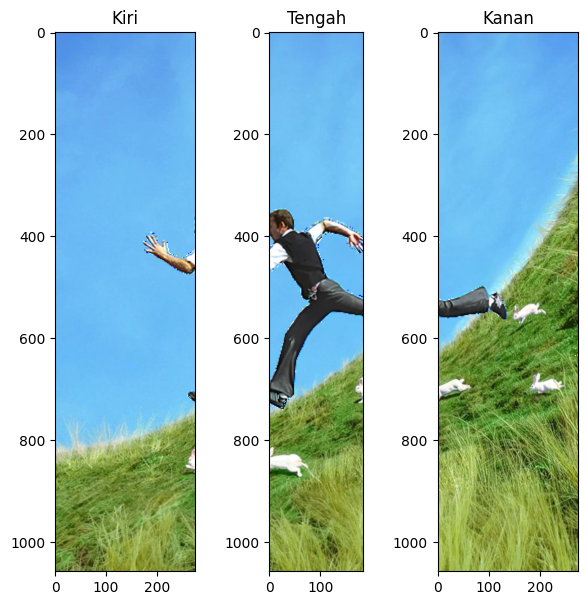

In [19]:
kiri = fungsi_slicing(final_citra, 0, 275, 'Y')
tengah = fungsi_slicing(final_citra, 275, 460, 'Y')
kanan = fungsi_slicing(final_citra, 460, 736, 'Y')

plt.figure(figsize=(7, 7))

plt.subplot(1, 3, 1)
plt.imshow(kiri)
plt.title("Kiri")

plt.subplot(1, 3, 2)
plt.imshow(tengah)
plt.title("Tengah")

plt.subplot(1, 3, 3)
plt.imshow(kanan)
plt.title("Kanan")

Kode di bawah ini mengubah bagian tengah gambar dari warna RGB jadi gambar hitam putih dengan `cv2.cvtColor`, lalu menghitung sebaran intensitas piksel pada gambar keabuan itu menggunakan fungsi `buat_hist`, dan terakhir menampilkan hasilnya sebagai histogram berwarna merah dengan judul "Histogram Bagian Tengah" supaya kita bisa melihat bagaimana nilai kecerahan tersebar di bagian tengah gambar.

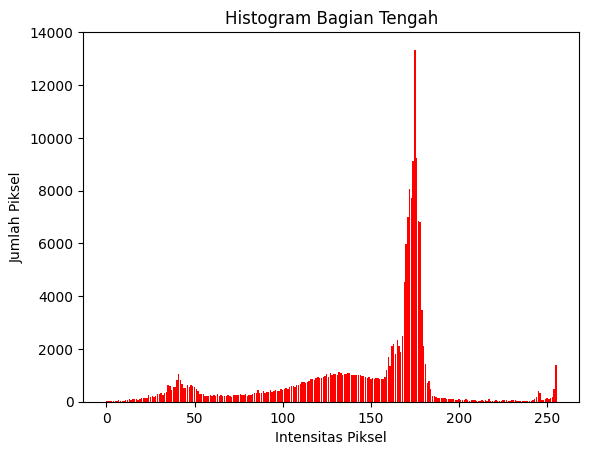

In [20]:
tengah_grayscale = cv2.cvtColor(tengah, cv2.COLOR_RGB2GRAY)
histogram_tengah = buat_hist(tengah_grayscale)
plot_histogram(histogram_tengah, "Histogram Bagian Tengah", "red")

In [21]:
def ekualisasi(citra):
    h, w = citra.shape

    hist = np.zeros(256, dtype=int)
    for i in range(h):
        for j in range(w):
            intensitas = citra[i, j]
            hist[intensitas] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (h * w)).astype(np.uint8)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

Fungsi `ekualisasi` di atas ini mengubah citra grayscale supaya kontrasnya lebih merata dengan cara menghitung dulu berapa banyak piksel untuk tiap nilai intensitas, lalu membuat distribusi kumulatif dari hitungan itu dan mengubahnya menjadi nilai baru yang disesuaikan antara 0 sampai 255, setelah itu setiap piksel diubah berdasarkan pemetaan baru tersebut sehingga gambar hasilnya memiliki penyebaran intensitas yang lebih baik dan detail bayangan maupun terang jadi lebih terlihat.

Kode di bawah ini pertama memisahkan bagian tengah gambar menjadi tiga channel warna yaitu biru, hijau, dan merah, lalu setiap channel itu diolah dengan fungsi `ekualisasi` supaya kontrasnya jadi lebih merata. Setelah itu ketiga channel yang sudah diekualisasi digabung lagi menjadi satu gambar warna penuh menggunakan `merge_channel`, dan hasilnya ditampilkan bersama-sama dalam satu figure dengan empat subplot, di mana tiga subplot pertama menunjukkan masing-masing channel yang sudah diekualisasi dengan palet warna sesuai dan subplot terakhir menampilkan gambar gabungan akhirnya.

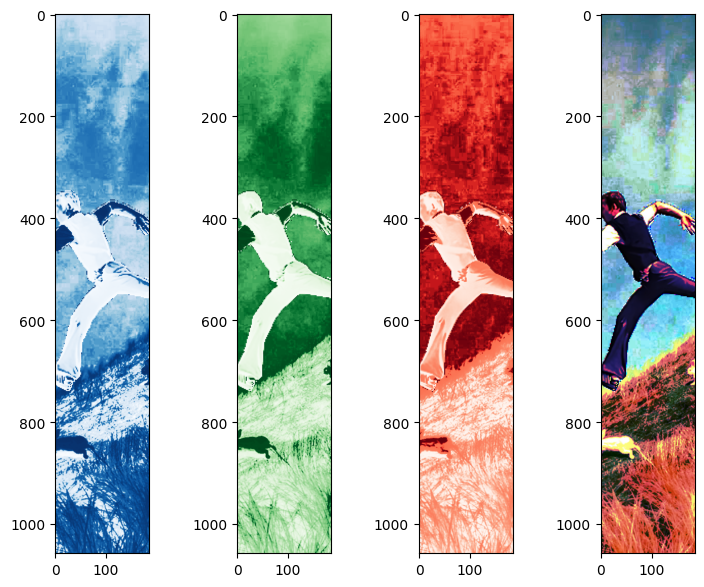

In [22]:
blue_tengah = tengah[:, :, 0]
green_tengah = tengah[:, :, 1]
red_tengah = tengah[:, :, 2]

blue_ekualisasi = ekualisasi(blue_tengah)
green_ekualisasi = ekualisasi(green_tengah)
red_ekualisasi = ekualisasi(red_tengah)

gabungan_tengah = merge_channel(blue_ekualisasi, green_ekualisasi, red_ekualisasi)

plt.figure(figsize=(9, 7))

plt.subplot(1, 4, 1)
plt.imshow(blue_ekualisasi, cmap='Blues')

plt.subplot(1, 4, 2)
plt.imshow(green_ekualisasi, cmap='Greens')

plt.subplot(1, 4, 3)
plt.imshow(red_ekualisasi, cmap='Reds')

plt.subplot(1, 4, 4)
plt.imshow(gabungan_tengah)

Kode di bawah ini mengubah gambar hasil gabungan bagian tengah menjadi gambar hitam putih agar hanya menyisakan nilai intensitas, kemudian menghitung sebaran intensitas piksel tersebut menggunakan fungsi histogram yang sudah dibuat sebelumnya, dan terakhir menampilkan hasilnya sebagai grafik batang berwarna merah sehingga kita bisa melihat bagaimana kecerahan pada bagian tengah gambar terdistribusi.

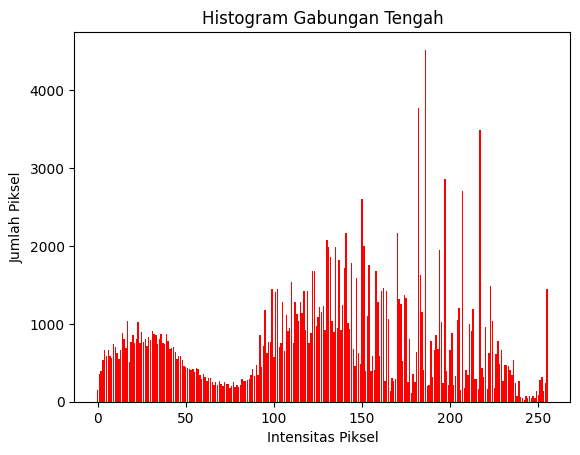

In [23]:
gabungan_tengah_grayscale = cv2.cvtColor(gabungan_tengah, cv2.COLOR_RGB2GRAY)
histogram_gabungan_tengah = buat_hist(gabungan_tengah_grayscale)
plot_histogram (histogram_gabungan_tengah, "Histogram Gabungan Tengah", "red")

In [24]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

Fungsi di atas ini menggabungkan dua citra dengan cara membuat kanvas baru yang ukurannya disesuaikan berdasarkan orientasi, jadi kalau orientasinya `'H'` citra akan disusun berdampingan secara horizontal sedangkan kalau bukan maka akan disusun secara vertikal. Pertama fungsi menghitung tinggi dan lebar gabungan yang dibutuhkan, lalu membuat array kosong dengan tipe data yang sama seperti citra awal, baik untuk citra grayscale maupun RGB, lalu menempelkan `citra1` dan `citra2` ke posisi yang benar di dalam array tersebut sehingga hasilnya menjadi satu citra gabungan utuh.

Kode di bawah ini pertama-tama menggabungkan bagian kiri gambar dengan bagian tengah yang sudah diekualisasi secara horizontal menggunakan fungsi merge_image, sehingga menghasilkan gabung1 yang merupakan kombinasi kedua bagian tersebut berdampingan. Selanjutnya, gabung1 digabungkan lagi dengan bagian kanan gambar secara horizontal untuk membuat gabung_final, yang merupakan gambar utuh yang terdiri dari kiri, tengah, dan kanan. Akhirnya, gambar gabungan akhir tersebut ditampilkan menggunakan plt.imshow dan plt.show agar kita bisa melihat hasil penggabungan keseluruhan secara visual di notebook.

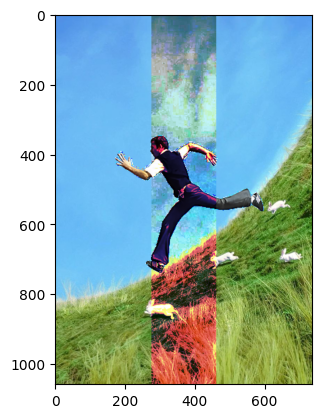

In [25]:
gabung1 = merge_image(kiri, gabungan_tengah, 'H')
gabung_final = merge_image(gabung1, kanan, 'H')

plt.imshow(gabung_final)
plt.show()

Baris kode di bawah ini mengubah gambar `gabung_final` menjadi citra keabuan dengan `cv2.cvtColor` supaya hanya menyisakan nilai intensitas, lalu menghitung berapa banyak piksel di setiap tingkat kecerahan dengan memanggil `buat_hist`, dan terakhir menampilkan hasilnya dalam bentuk histogram berjudul "Histogram Final" dengan warna merah agar kita bisa melihat sebaran kecerahan gambar akhir secara visual.

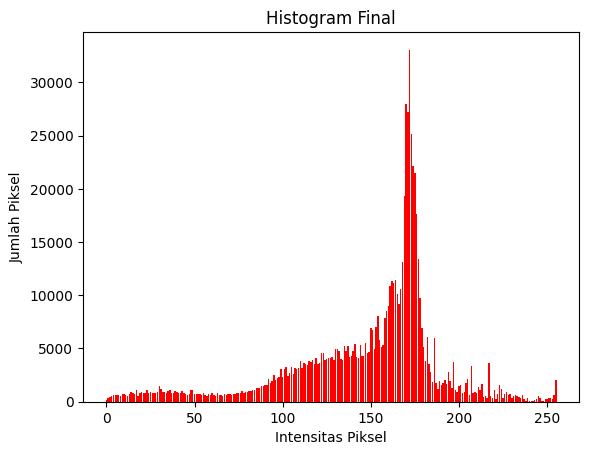

In [26]:
gabung_final_grayscale = cv2.cvtColor(gabung_final, cv2.COLOR_RGB2GRAY)
histogram_gabung_final = buat_hist(gabung_final_grayscale)
plot_histogram (histogram_gabung_final, "Histogram Final", "red")

menunjukkan langkah-langkah pengolahan citra secara bertahap dengan cara yang cukup sederhana. Pertama, gambar latar dibaca dan diubah dari format BGR ke RGB agar tampil benar di matplotlib, lalu setiap saluran warna merah, hijau, dan biru dipisah dan ditampilkan secara terpisah supaya kita bisa melihat kontribusi masing-masing channel. Selanjutnya dibuat fungsi untuk membuat histogram manual dan menampilkan histogram, lalu histogram untuk setiap channel background serta target dihitung dan ditampilkan, sehingga kita bisa membandingkan sebaran intensitas pikselnya.

Kemudian dilakukan spesifikasi histogram untuk setiap channel background terhadap targetnya, yaitu mencari pemetaan intensitas yang membuat distribusi nilai cahaya channel asal mendekati target. Hasil spesifikasi tiap channel lalu digabung menjadi satu gambar warna yang baru. Pada bagian lain notebook juga dibaca gambar foreground dan dilakukan operasi “dilatasi” sederhana untuk memperbesar channel-channel foreground, setelah itu foreground yang sudah diperbesar digabungkan dengan background hasil spesifikasi menggunakan aturan piksel hitam diganti background. Hasil akhir komposit ini kemudian diubah ke grayscale dan historgramnya dihitung.

Terakhir, gambar hasil komposit dibagi menjadi tiga bagian secara horizontal, bagian tengah dianalisis lebih lanjut dengan mengubahnya ke grayscale dan melakukan ekualisasi pada setiap channel warna. Bagian tengah yang sudah diekualisasi digabung lagi menjadi gambar warna dan seluruh bagian kiri, tengah, kanan disusun kembali menjadi gambar akhir. Dengan cara ini notebook memperlihatkan alur kerja pengolahan citra: membaca gambar, memisah channel, menganalisis histogram, melakukan spesifikasi histogram, menggabungkan citra, dan meningkatkan kontras pada area tertentu, semuanya dengan kode yang mudah diikuti oleh mahasiswa.